# NB01 — Gap-Fill Landscape

Characterize the 42 gap-fill reactions against Rosetta evidence.
For each reaction: confidence tier, evidence channels, and number of Swiss-Prot proteins linked via EC.

**Inputs**: `gapfill-rxn-genome-media.txt`, Rosetta parquet files

**Outputs**: `data/gapfill_landscape.csv`, `figures/gapfill_evidence_coverage.png`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

ROSETTA = Path('../..') / 'rosetta' / 'data'
USER_DATA = Path('..') / 'user_data'
DATA_OUT = Path('..') / 'user_data'
FIG_OUT = Path('..') / 'figures'
DATA_OUT.mkdir(exist_ok=True)
FIG_OUT.mkdir(exist_ok=True)

assert (ROSETTA / 'evidence_integration_summary.parquet').exists(), \
    "Run the Rosetta project first (projects/rosetta/) to generate parquet outputs."

## 1. Load Gap-Fill Reactions

In [2]:
gapfill_records = []
with open(USER_DATA / 'gapfill-rxn-genome-media.txt') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 4:
            rxn = parts[0]
            genomes = parts[1].split(',')
            direction = parts[2]
            media = parts[3].split(',')
            gapfill_records.append({
                'rxn': rxn,
                'n_genomes': len(genomes),
                'direction': direction,
                'media': media
            })

gapfill_df = pd.DataFrame(gapfill_records)
print(f"Gap-fill reactions: {len(gapfill_df)}")
print(f"Genomes affected: {gapfill_df['n_genomes'].sum()} total assignments")
gapfill_df.head(10)

Gap-fill reactions: 42
Genomes affected: 1404 total assignments


,rxn,n_genomes,direction,media
0,rxn00084,47,0,[Biolog_D-Fucose]
1,rxn00128,48,0,"[Biolog_D-Arabitol, Biolog_Salicin, Biolog_D-F..."
2,rxn00141,42,0,[Biolog_D-Fucose]
3,rxn00317,48,0,[Biolog_D-Fucose]
4,rxn00510,1,0,[Biolog_D-Fucose]
5,rxn00575,6,0,"[Biolog_Stachyose, Biolog_D-Raffinose]"
6,rxn00577,8,0,"[Biolog_Stachyose, Biolog_D-Raffinose]"
7,rxn00738,48,0,"[Biolog_D-Arabitol, Biolog_Salicin, Biolog_D-F..."
8,rxn01327,3,0,[Biolog_Salicin]
9,rxn01361,48,0,[Biolog_D-Fucose]


## 2. Cross-Reference with Rosetta Evidence

In [3]:
evidence = pd.read_parquet(ROSETTA / 'evidence_integration_summary.parquet')
print(f"Rosetta reactions: {len(evidence):,}")

gapfill_rxns = set(gapfill_df['rxn'])
gf_evidence = evidence[evidence['rxn_bare'].isin(gapfill_rxns)].copy()

missing_from_rosetta = gapfill_rxns - set(gf_evidence['rxn_bare'])
print(f"Gap-fill reactions in Rosetta: {len(gf_evidence)} / {len(gapfill_rxns)}")
if missing_from_rosetta:
    print(f"Not in Rosetta (not mass-balanced?): {missing_from_rosetta}")

Rosetta reactions: 34,343
Gap-fill reactions in Rosetta: 40 / 42
Not in Rosetta (not mass-balanced?): {'rxn10966', 'rxn04656'}


In [4]:
merged = gapfill_df.merge(gf_evidence, left_on='rxn', right_on='rxn_bare', how='left')
merged['confidence'] = merged['confidence'].fillna('missing')

channel_cols = ['T1_ec', 'T1_brenda', 'T1_rhea', 'T2_eggnog_ec', 'T2_bakta_ec',
                'T3_paperblast', 'T3_seedclass', 'T3_besthitmetacyc_ec',
                'T3_besthitmetacyc_rxnid', 'RAST']

print("\nConfidence distribution:")
print(merged['confidence'].value_counts().to_string())
print(f"\nEvidence channel coverage for gap-fill reactions:")
for col in channel_cols:
    if col in merged.columns:
        n = merged[col].sum()
        print(f"  {col}: {n} / {len(merged)} ({100*n/len(merged):.0f}%)")


Confidence distribution:
confidence
high       24
none       14
missing     2
medium      1
low         1

Evidence channel coverage for gap-fill reactions:
  T1_ec: 25 / 42 (60%)
  T1_brenda: 20 / 42 (48%)
  T1_rhea: 18 / 42 (43%)
  T2_eggnog_ec: 20 / 42 (48%)
  T2_bakta_ec: 21 / 42 (50%)
  T3_paperblast: 25 / 42 (60%)
  T3_seedclass: 21 / 42 (50%)
  T3_besthitmetacyc_ec: 11 / 42 (26%)
  T3_besthitmetacyc_rxnid: 1 / 42 (2%)
  RAST: 23 / 42 (55%)


## 3. Count Swiss-Prot Proteins per Reaction

In [5]:
ec_rxn = pd.read_parquet(ROSETTA / 'ec_to_reaction.parquet')
protein_ec = pd.read_parquet(ROSETTA / 'uniprot_native_protein_ec.parquet')
swissprot = pd.read_parquet(ROSETTA / 'swissprot_proteins.parquet')
sp_ids = set(swissprot.iloc[:, 0])

print(f"EC→reaction pairs: {len(ec_rxn):,}")
print(f"Protein→EC pairs: {len(protein_ec):,}")
print(f"Swiss-Prot proteins: {len(sp_ids):,}")

EC→reaction pairs: 22,823
Protein→EC pairs: 27,639,185
Swiss-Prot proteins: 574,627


In [6]:
gf_ec = ec_rxn[ec_rxn['rxn_bare'].isin(gapfill_rxns)][['rxn_bare', 'ec']]
print(f"EC numbers for gap-fill reactions: {gf_ec['ec'].nunique()}")

gf_ecs = set(gf_ec['ec'])
sp_protein_ec = protein_ec[protein_ec['ec'].isin(gf_ecs) & protein_ec['protein'].isin(sp_ids)]
print(f"Swiss-Prot proteins with matching ECs: {sp_protein_ec['protein'].nunique():,}")

sp_per_rxn = (
    gf_ec
    .merge(sp_protein_ec[['protein', 'ec']], on='ec')
    .groupby('rxn_bare')['protein']
    .nunique()
    .reset_index()
    .rename(columns={'protein': 'n_swissprot', 'rxn_bare': 'rxn'})
)

merged = merged.merge(sp_per_rxn, on='rxn', how='left')
merged['n_swissprot'] = merged['n_swissprot'].fillna(0).astype(int)

print(f"\nReactions with Swiss-Prot candidates: {(merged['n_swissprot'] > 0).sum()} / {len(merged)}")
print(f"Total unique Swiss-Prot candidates: {sp_per_rxn['n_swissprot'].sum():,}")

EC numbers for gap-fill reactions: 28


Swiss-Prot proteins with matching ECs: 1,140

Reactions with Swiss-Prot candidates: 25 / 42
Total unique Swiss-Prot candidates: 1,303


## 4. Summary Table

In [7]:
summary_cols = ['rxn', 'n_genomes', 'confidence', 'n_channels', 'n_swissprot']
available_cols = [c for c in summary_cols if c in merged.columns]
summary = merged[available_cols].sort_values('n_swissprot', ascending=False)

print("Gap-Fill Reaction Landscape")
print("=" * 70)
display(summary)

summary.to_csv(DATA_OUT / 'gapfill_landscape.csv', index=False)
print(f"\nSaved to {DATA_OUT / 'gapfill_landscape.csv'}")

Gap-Fill Reaction Landscape


,rxn,n_genomes,confidence,n_channels,n_swissprot
24,rxn04660,48,high,5.0,369
9,rxn01361,48,high,8.0,99
14,rxn02107,48,high,8.0,98
22,rxn04658,48,high,5.0,96
18,rxn03978,47,high,9.0,79
12,rxn01737,5,high,6.0,76
5,rxn00575,6,high,8.0,73
23,rxn04659,48,high,5.0,71
13,rxn01927,3,high,9.0,57
7,rxn00738,48,high,8.0,54



Saved to ../data/gapfill_landscape.csv


## 5. Evidence Coverage Figure

/tmp/ipykernel_8917/2319167135.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = merged.set_index('rxn')[heatmap_cols].fillna(False).astype(int)


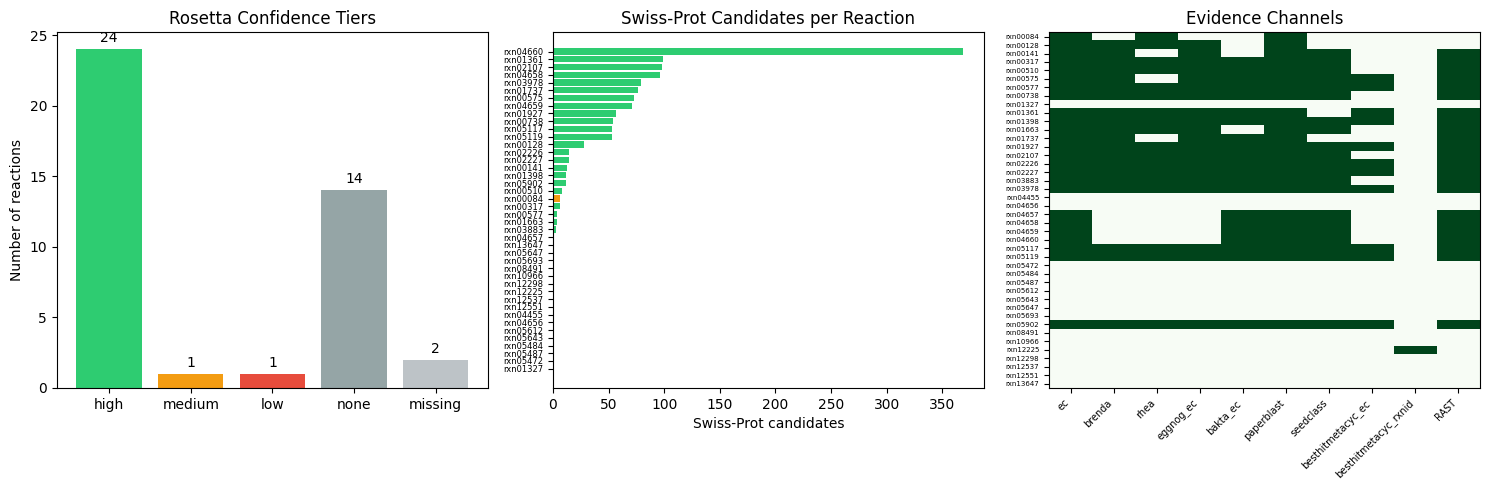

Saved to ../figures/gapfill_evidence_coverage.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Confidence tier distribution
tier_order = ['high', 'medium', 'low', 'none', 'missing']
tier_colors = {'high': '#2ecc71', 'medium': '#f39c12', 'low': '#e74c3c', 'none': '#95a5a6', 'missing': '#bdc3c7'}
tier_counts = merged['confidence'].value_counts().reindex(tier_order).fillna(0)
bars = axes[0].bar(tier_counts.index, tier_counts.values,
                   color=[tier_colors[t] for t in tier_counts.index])
axes[0].set_ylabel('Number of reactions')
axes[0].set_title('Rosetta Confidence Tiers')
for bar, val in zip(bars, tier_counts.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(int(val)), ha='center', va='bottom', fontsize=10)

# Panel 2: Swiss-Prot candidates per reaction
sp_sorted = merged.sort_values('n_swissprot', ascending=True)
colors = [tier_colors.get(c, '#95a5a6') for c in sp_sorted['confidence']]
axes[1].barh(range(len(sp_sorted)), sp_sorted['n_swissprot'], color=colors)
axes[1].set_yticks(range(len(sp_sorted)))
axes[1].set_yticklabels(sp_sorted['rxn'], fontsize=6)
axes[1].set_xlabel('Swiss-Prot candidates')
axes[1].set_title('Swiss-Prot Candidates per Reaction')

# Panel 3: Evidence channels heatmap
heatmap_cols = [c for c in channel_cols if c in merged.columns]
if heatmap_cols:
    heatmap_data = merged.set_index('rxn')[heatmap_cols].fillna(False).astype(int)
    heatmap_data = heatmap_data.sort_index()
    im = axes[2].imshow(heatmap_data.values, aspect='auto', cmap='Greens', interpolation='nearest')
    axes[2].set_yticks(range(len(heatmap_data)))
    axes[2].set_yticklabels(heatmap_data.index, fontsize=5)
    axes[2].set_xticks(range(len(heatmap_cols)))
    axes[2].set_xticklabels([c.replace('T1_', '').replace('T2_', '').replace('T3_', '')
                             for c in heatmap_cols], rotation=45, ha='right', fontsize=7)
    axes[2].set_title('Evidence Channels')

plt.tight_layout()
plt.savefig(FIG_OUT / 'gapfill_evidence_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {FIG_OUT / 'gapfill_evidence_coverage.png'}")

## 6. Partition Summary

Partition the 42 reactions by approach needed in subsequent notebooks.

In [9]:
has_sp = merged[merged['n_swissprot'] > 0]
no_sp_has_evidence = merged[(merged['n_swissprot'] == 0) & (merged['confidence'].isin(['high', 'medium', 'low']))]
no_evidence = merged[merged['confidence'] == 'none']
missing = merged[merged['confidence'] == 'missing']

print("Partition for downstream analysis:")
print(f"  Direct Swiss-Prot candidates:     {len(has_sp)} reactions")
print(f"  Rosetta evidence, no Swiss-Prot:   {len(no_sp_has_evidence)} reactions (need TrEMBL or broader EC)")
print(f"  No Rosetta evidence:               {len(no_evidence)} reactions (need proxy via reaction_similarity)")
print(f"  Not in Rosetta (not mass-balanced): {len(missing)} reactions")
print()
print("NB02 will assemble candidates for the first group directly.")
print("The no-evidence and missing groups will need the reaction_similarity proxy approach.")

Partition for downstream analysis:
  Direct Swiss-Prot candidates:     25 reactions
  Rosetta evidence, no Swiss-Prot:   1 reactions (need TrEMBL or broader EC)
  No Rosetta evidence:               14 reactions (need proxy via reaction_similarity)
  Not in Rosetta (not mass-balanced): 2 reactions

NB02 will assemble candidates for the first group directly.
The no-evidence and missing groups will need the reaction_similarity proxy approach.
